In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys

nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
import warnings

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

In [63]:
PREDICT_BY_YEAR = False
PREDICT_YEARS = 4
MATURITY_YEARS = 50

In [37]:
# import mysql.connector

# dolt = mysql.connector.connect(
#     host="localhost", port=3306, user="root", database="earnings"
# )

In [38]:
from collections import defaultdict

# cursor = dolt.cursor()
# cursor.execute("select * from income_statement where period = 'Quarter'")
# field_names = [i[0] for i in cursor.description]
# dolt_data = defaultdict(list)
# for row in cursor.fetchall():
#     for i, v in enumerate(row):
#         dolt_data[field_names[i]].append(v)
# qdf = pd.DataFrame(dolt_data)
df_income = pd.read_csv("../data/income_statement.csv")
df_income = df_income[df_income["period"] == "Quarter"]

In [39]:
# cursor.execute("select * from balance_sheet_assets where period = 'Quarter'")
# field_names = [i[0] for i in cursor.description]
# balance = defaultdict(list)
# for row in cursor.fetchall():
#     for i, v in enumerate(row):
#         balance[field_names[i]].append(v)
# balance_df = pd.DataFrame(balance)
df_assets = pd.read_csv("../data/balance_sheet_assets.csv")
df_assets = df_assets[df_assets["period"] == "Quarter"]
df_assets["cash_and_equivalents"] /= 1_000_000

In [40]:
# cursor.execute("select * from balance_sheet_liabilities where period = 'Quarter'")
# field_names = [i[0] for i in cursor.description]
# liability = defaultdict(list)
# for row in cursor.fetchall():
#     for i, v in enumerate(row):
#         liability[field_names[i]].append(v)
# liability_df = pd.DataFrame(liability)
df_liabilities = pd.read_csv("../data/balance_sheet_liabilities.csv")
df_liabilities = df_liabilities[df_liabilities["period"] == "Quarter"]
df_liabilities["long_term_debt"] /= 1_000_000
df_liabilities["minority_interest"] /= 1_000_000

In [41]:
sp500 = pd.read_csv("../data/sp500_members.csv")
sp500_df = df_income[df_income["act_symbol"].isin(sp500["Symbol"])]
sp500_df["net_income"] /= 1_000_000
sp500_df["average_shares"] /= 1_000_000
sp500_df

,act_symbol,date,period,sales,cost_of_goods,gross_profit,selling_administrative_depreciation_amortization_expenses,income_after_depreciation_and_amortization,non_operating_income,interest_expense,...,investment_gains,other_income,income_from_continuing_operations,extras_and_discontinued_operations,net_income,income_before_depreciation_and_amortization,depreciation_and_amortization,average_shares,diluted_eps_before_non_recurring_items,diluted_net_eps
4,A,2016-07-31,Quarter,1044000000,502000000,542000000,396000000,146000000,5000000,17000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.49,0.38
5,A,2016-10-31,Quarter,1111000000,523000000,588000000,405000000,183000000,-13000000,19000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.59,0.37
7,A,2017-01-31,Quarter,1067000000,493000000,574000000,368000000,206000000,7000000,20000000,...,0,0,168000000,0,168.0,NaN,NaN,326.0,0.53,0.52
8,A,2017-04-30,Quarter,1102000000,510000000,592000000,391000000,201000000,10000000,20000000,...,0,0,164000000,0,164.0,NaN,NaN,325.0,0.58,0.50
9,A,2017-07-31,Quarter,1114000000,518000000,596000000,395000000,201000000,11000000,19000000,...,0,0,175000000,0,175.0,NaN,NaN,326.0,0.59,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198974,ZTS,2023-06-30,Quarter,2180000000,607000000,1573000000,643000000,930000000,0,58000000,...,0,0,670000000,0,671.0,NaN,NaN,462.9,1.41,1.45
198975,ZTS,2023-09-30,Quarter,2151000000,638000000,1513000000,737000000,776000000,0,59000000,...,0,0,596000000,0,596.0,NaN,NaN,461.4,1.36,1.29
198976,ZTS,2023-12-31,Quarter,2213000000,728000000,1485000000,776000000,709000000,0,59000000,...,0,0,523000000,0,525.0,NaN,NaN,460.1,1.24,1.14
198978,ZTS,2024-03-31,Quarter,2190000000,643000000,1547000000,742000000,805000000,0,58000000,...,0,0,599000000,0,599.0,NaN,NaN,458.8,1.38,1.31


In [42]:
ticker_to_deg = {}

for tkr in sp500_df["act_symbol"].drop_duplicates():
    net_income = sp500_df[sp500_df["act_symbol"] == tkr]["net_income"].dropna()
    net_income_diff = net_income
    if net_income.size > 20:
        degree = 0
        test = sm.tsa.stattools.adfuller(net_income)
        while test[1] > 0.001 and degree < 3:
            net_income_diff = net_income_diff.diff().fillna(0)
            test = sm.tsa.stattools.adfuller(net_income_diff)
            degree += 1
        if degree == 3:
            print(f"Ticker {tkr} is likely not stationary")
        else:
            ticker_to_deg[tkr] = degree

Ticker ACGL is likely not stationary
Ticker ADP is likely not stationary
Ticker ALB is likely not stationary
Ticker ALLE is likely not stationary
Ticker ANET is likely not stationary
Ticker AVGO is likely not stationary
Ticker AXON is likely not stationary
Ticker BIO is likely not stationary
Ticker BKR is likely not stationary
Ticker CAG is likely not stationary
Ticker CHRW is likely not stationary
Ticker CINF is likely not stationary
Ticker CMI is likely not stationary
Ticker CPRT is likely not stationary
Ticker CTLT is likely not stationary
Ticker CTVA is likely not stationary
Ticker DHI is likely not stationary
Ticker DOW is likely not stationary
Ticker DVN is likely not stationary
Ticker ED is likely not stationary
Ticker ETSY is likely not stationary
Ticker EVRG is likely not stationary
Ticker FAST is likely not stationary
Ticker GOOG is likely not stationary
Ticker GOOGL is likely not stationary
Ticker HLT is likely not stationary
Ticker HOLX is likely not stationary
Ticker JBL i

In [43]:
import warnings

warnings.filterwarnings("ignore")

tkr_to_forecast = {}
for tkr in ticker_to_deg:
    deg = ticker_to_deg[tkr]
    net_income = (
        sp500_df[sp500_df["act_symbol"] == tkr]["net_income"]
        .fillna(0)
        .astype(np.float64)
    )
    endog = net_income
    for _ in range(deg):
        endog = endog.diff().fillna(0)

    mod = sm.tsa.ARIMA(
        endog, order=(0, max(deg, 1), 1), seasonal_order=(0, max(deg, 1), 1, 4)
    )
    res = mod.fit()

    n_predictions = PREDICT_YEARS * 4
    if deg == 0:
        tkr_to_forecast[tkr] = (
            pd.Series(np.r_[net_income.to_numpy(), res.predict(n_predictions)]),
            res.aic,
        )
    else:
        predict_val = np.r_[
            net_income.iloc[:deg], endog.iloc[deg:], res.predict(n_predictions)
        ]
        tkr_to_forecast[tkr] = (
            pd.Series(
                np.r_[
                    net_income.to_numpy(),
                    np.array(predict_val).cumsum()[-n_predictions:],
                ]
            ),
            res.aic,
        )
    print(tkr, res.aic, res.bic)

A 356.7747333159505 360.6622439139635
AAL 452.2764351557593 456.1639457537723
AAPL 472.26725082862635 475.5403781887013
ABBV 482.0780572683865 485.96556786639945
ABT 437.0945923377077 440.98210293572066
ACN 357.1993451206797 360.4724724807547
ADBE 428.7219683412296 432.71858187175525
ADI 386.48643612311264 390.48304965363826
ADM 384.1278861964159 388.01539679442885
ADSK 381.7261092616117 385.6136198596247
AEE 314.52622133306585 317.7993486931408
AEP 396.6844592160475 400.5719698140605
AES 398.5814943058493 402.35578391991373
AFL 418.5474026461084 422.3216922601729
AIG 515.25378890713 519.141299505143
AIZ 371.810172671218 375.697683269231
AJG 336.142986669925 340.03049726793796
AKAM 263.47143511296053 267.245724727025
ALGN 382.111325059037 385.88561467310143
ALL 459.30229203602295 463.1898026340359
AMAT 416.703556400391 420.7001699309166
AMCR 215.1070798874804 217.60671991964907
AMD 404.00960156403005 407.7838911780945
AME 286.93317622324207 290.82068682125504
AMGN 477.8070454128916 481

In [44]:
all_aic = pd.Series([tkr_to_forecast[tkr][1] for tkr in tkr_to_forecast])
all_aic.describe()

count    407.000000
mean     383.660490
std       71.851525
min      178.417379
25%      334.653275
50%      380.230821
75%      431.505498
max      586.474650
dtype: float64

In [45]:
import yfinance as yf

close_data = yf.Tickers(list(tkr_to_forecast.keys())).history()

[*********************100%***********************]  407 of 407 completed

3 Failed downloads:
['FLT', 'PXD', 'WRK']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")')


In [70]:
import numpy_financial as npf

diff = {}
for tkr in tkr_to_forecast:
    fc, aic = tkr_to_forecast[tkr]
    cash_flow = [
        sum(fc[-4 * PREDICT_YEARS :][i * 4 : (i + 1) * 4]) for i in range(PREDICT_YEARS)
    ]
    if (
        not df_assets[df_assets["act_symbol"] == tkr].empty
        and not df_liabilities[df_liabilities["act_symbol"] == tkr].empty
    ):
        cash = float(
            df_assets[df_assets["act_symbol"] == tkr]["cash_and_equivalents"].iloc[-1]
        )
        debt = float(
            df_liabilities[df_liabilities["act_symbol"] == tkr]["long_term_debt"].iloc[
                -1
            ]
        ) + float(
            df_liabilities[df_liabilities["act_symbol"] == tkr][
                "minority_interest"
            ].iloc[-1]
        )
        shares = float(
            sp500_df[sp500_df["act_symbol"] == tkr]["average_shares"].iloc[-1]
        )
        price = close_data.Close.loc[:, tkr].iloc[-1]
        if aic < 350:
            discount_rate = 0.08
            terminal_rate = 0.05
            maturity = (
                (cash_flow[-1] * (1 + terminal_rate)) / (discount_rate - terminal_rate)
            ) / np.pow((1 + discount_rate), PREDICT_YEARS)
            val = (
                npf.npv(discount_rate, np.append(0, cash_flow)) + maturity + cash - debt
            )
            est_price = val / shares
            diff[tkr] = {
                "price": price,
                "est_price": est_price,
                "npv": npf.npv(discount_rate, np.append(0, cash_flow)),
                "cash": cash,
                "debt": debt,
                "shares": shares,
            }

In [71]:
df = pd.DataFrame(diff.values(), index=diff.keys())
df["diff"] = df.est_price - df.price
df["diff_pct"] = (df.est_price - df.price) / df.price * 100
df["quantile"] = pd.qcut(df["diff_pct"], 5, labels=False)
print(df.sort_values(["quantile", "diff_pct"], ascending=False).dropna().to_string())

            price     est_price           npv     cash     debt   shares          diff    diff_pct  quantile
CTRA    24.889999    143.053878   9022.038874   1329.0   2071.0   742.00    118.163878  474.744400       4.0
PHM    139.199997    690.167334  13874.625228   1446.0   1650.0   211.20    550.967337  395.809877       4.0
NTRS    92.169998    390.374931   4891.016691  52015.0   6817.0   203.74    298.204933  323.537961       4.0
AEE     86.449997    332.763965  12141.647197     19.0  16280.0   266.80    246.313968  284.920736       4.0
GEN     27.750000     92.328805   4489.909046    644.0   7190.0   627.00     64.578805  232.716414       4.0
LKQ     39.040001    125.506585   3482.811606    276.0   4253.0   265.60     86.466585  221.482025       4.0
CTAS   208.050003    660.466017   7044.712546    342.0   2026.0   103.33    452.416014  217.455423       4.0
GL     107.779999    339.771082   3312.132534    188.0   1630.0    91.44    231.991083  215.245023       4.0
WRB     58.570000  

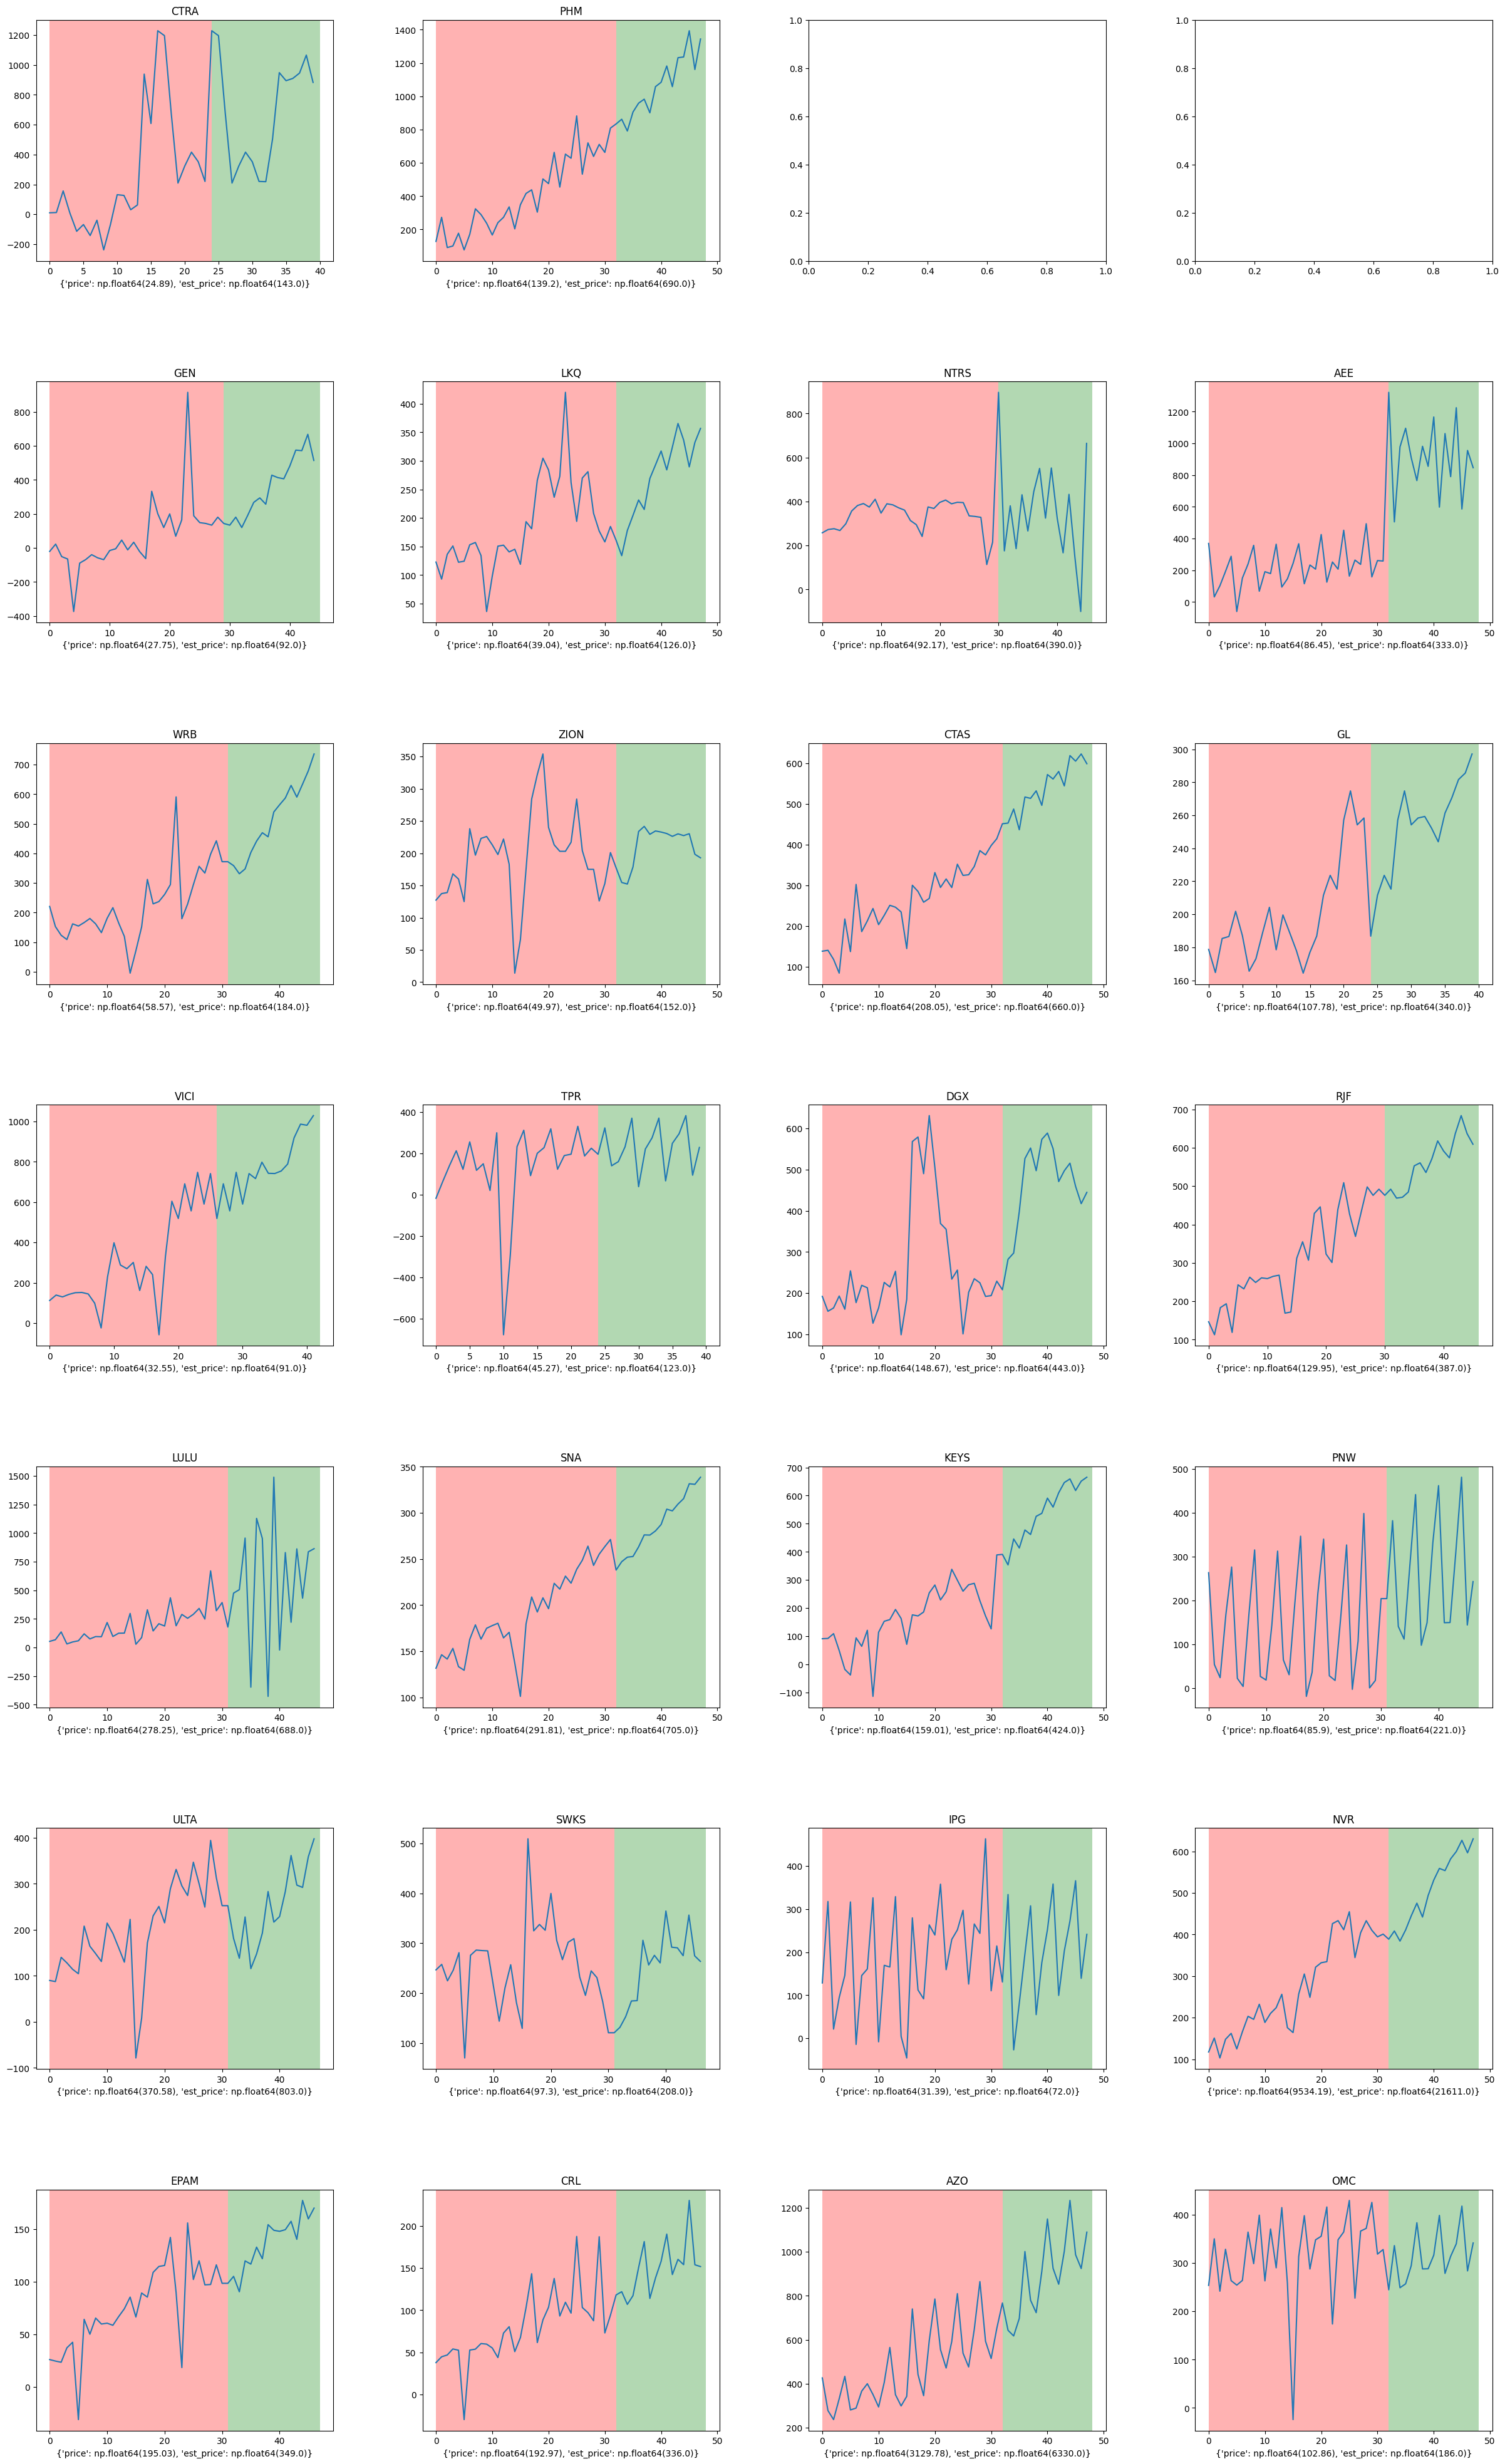

In [73]:
def plot_tkr(tkr, ax):
    actual = sp500_df[sp500_df["act_symbol"] == tkr][["date", "net_income"]]
    actual["net_income"] = actual["net_income"].astype(np.float64)
    forecast = pd.Series(tkr_to_forecast[tkr][0])
    plt = forecast.plot(title=tkr, ax=ax)
    plt.set_xlabel(
        {
            "price": np.round(diff[tkr]["price"], 2),
            "est_price": np.round(diff[tkr]["est_price"]),
        }
    )
    plt.axvspan(
        0,
        forecast.size - (PREDICT_YEARS * 4),
        facecolor="red",
        edgecolor="none",
        alpha=0.3,
    )
    plt.axvspan(
        forecast.size - (PREDICT_YEARS * 4),
        forecast.size,
        facecolor="green",
        edgecolor="none",
        alpha=0.3,
    )


def plot_quantile(quantile):
    q4 = df[df["quantile"] == quantile].sort_values("diff_pct", ascending=False)
    fig, axes = plt.subplots(
        nrows=int(np.ceil(len(q4.index) / 4)), ncols=4, figsize=(30, 50)
    )
    fig.subplots_adjust(wspace=0.3, hspace=0.5)
    for i, tkr in enumerate(q4.index):
        plot_tkr(
            tkr,
            axes[0 if i == 0 else int(np.ceil((i - 1) / 4)), i % 4],
        )


plot_quantile(4)

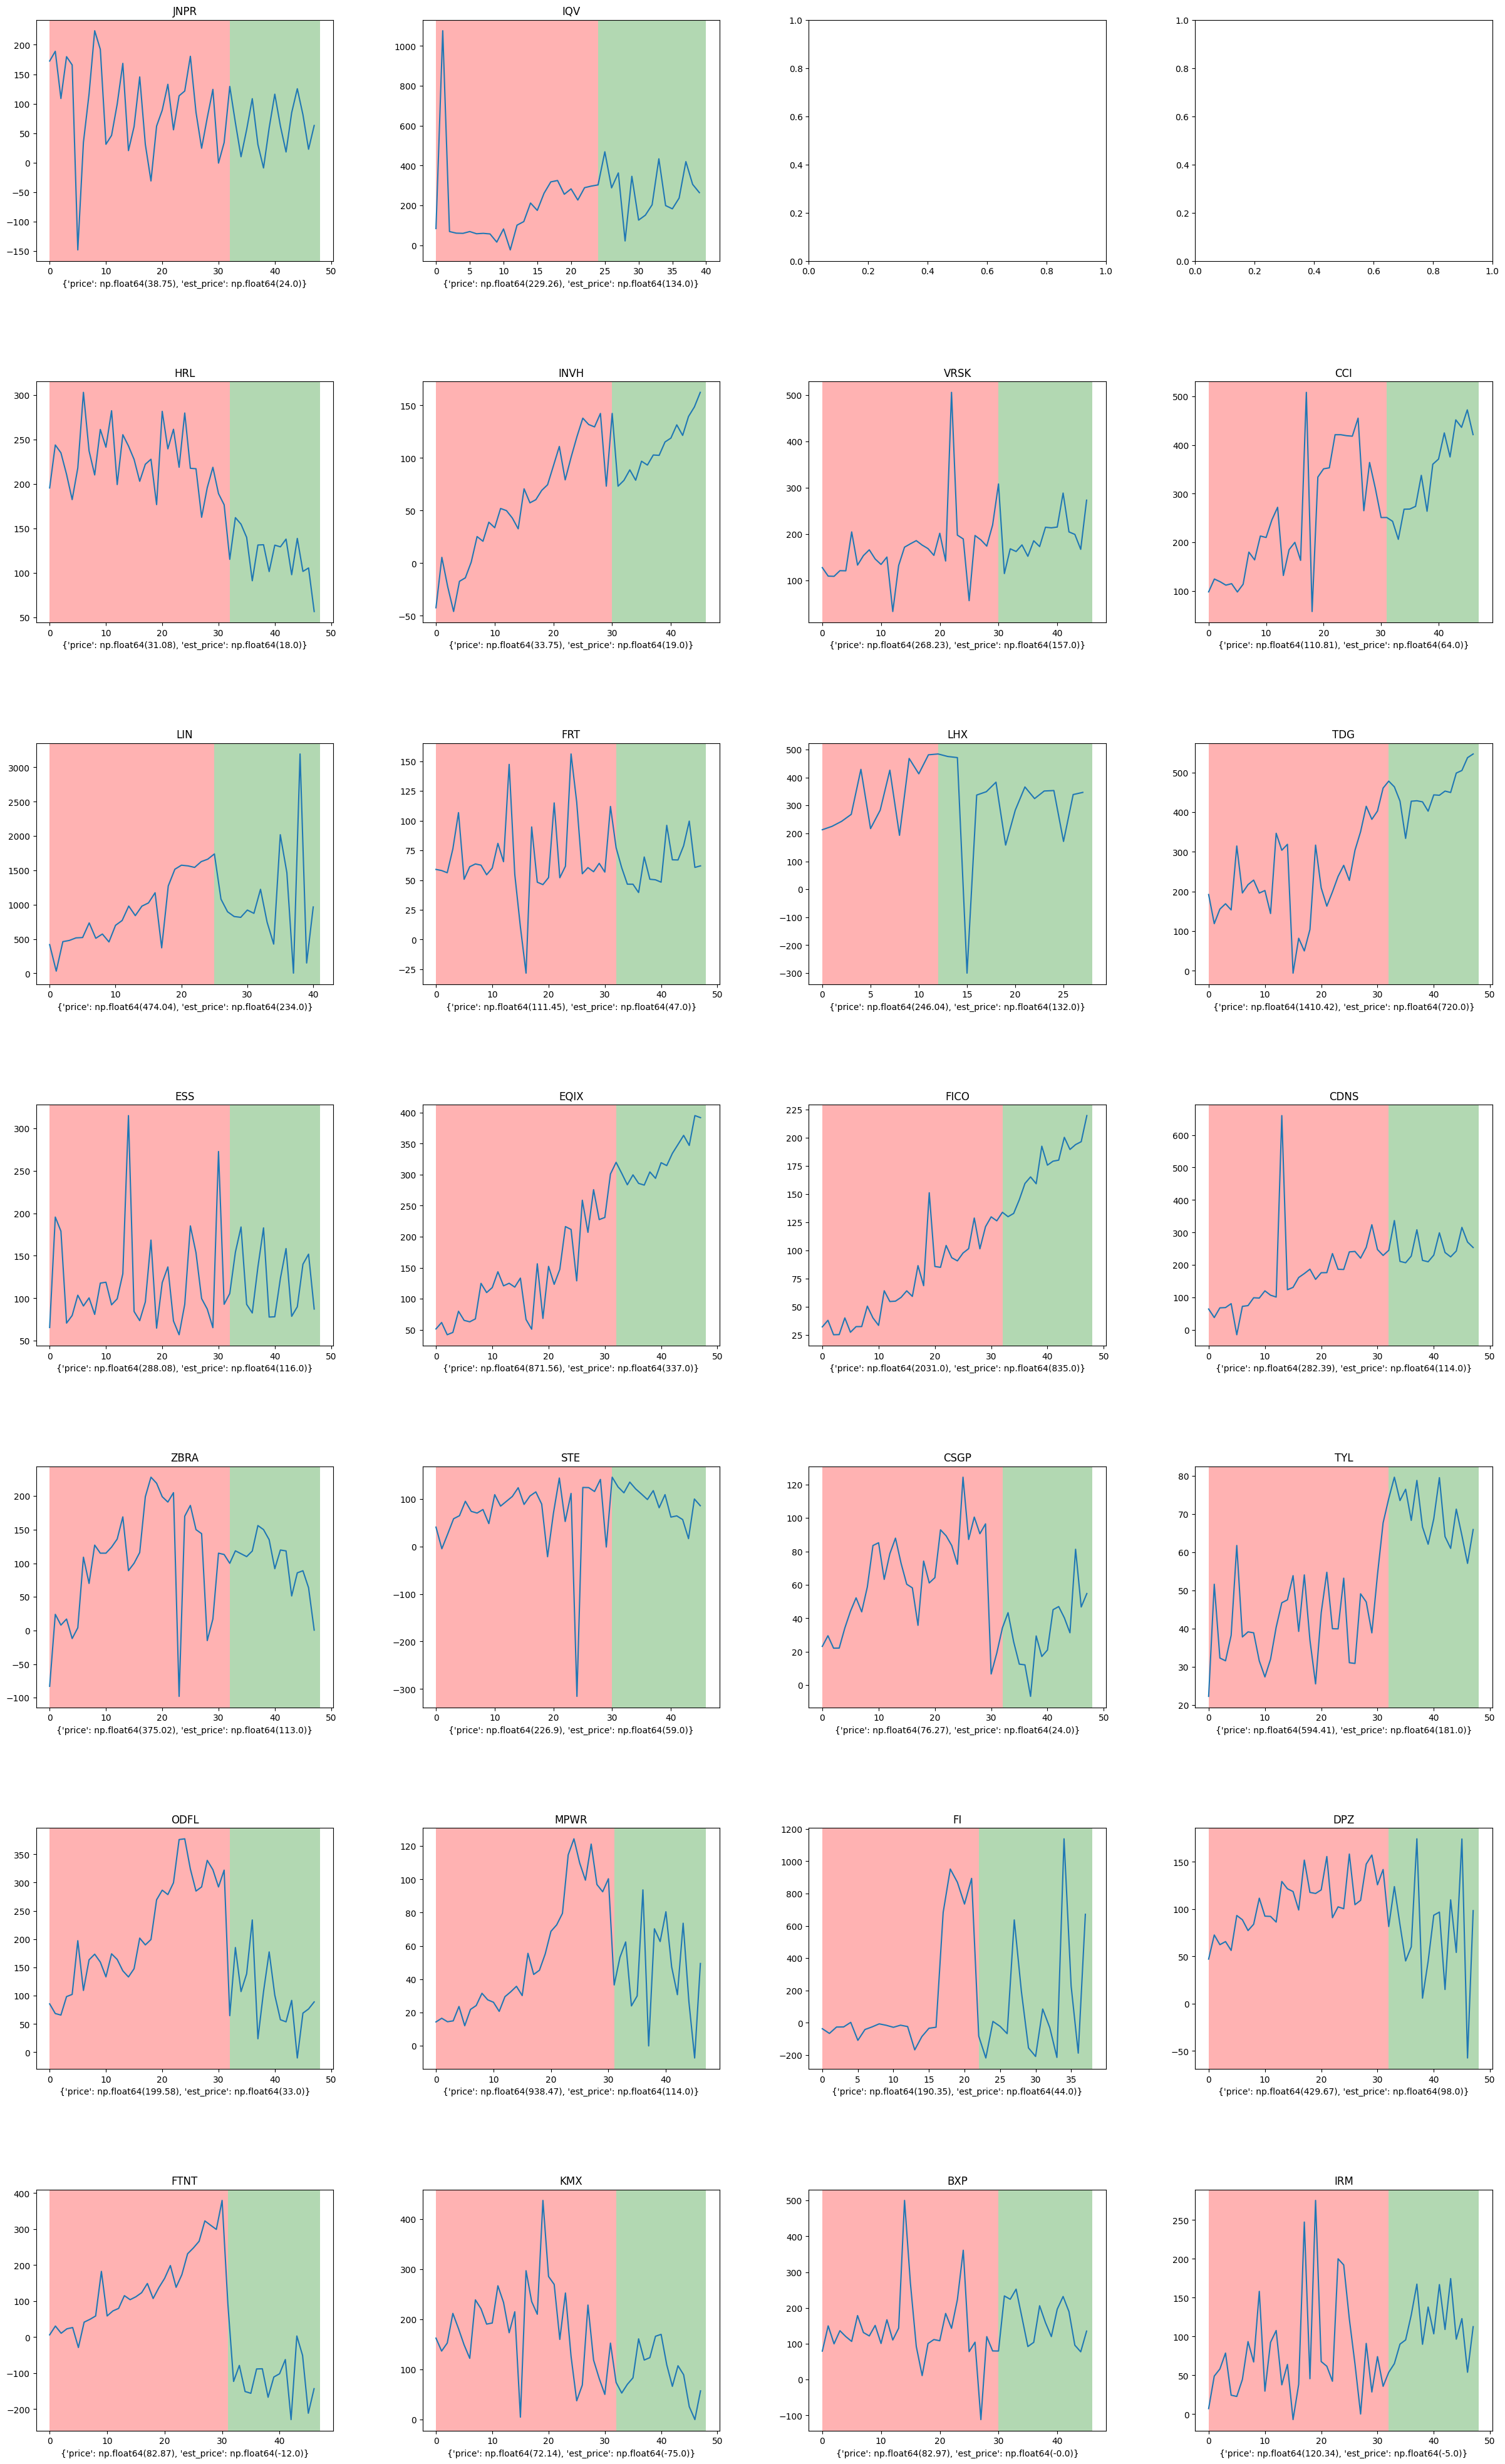

In [74]:
plot_quantile(0)